<a href="https://colab.research.google.com/github/gerardkutsukawa/data-analytics-portfolio/blob/main/KutsukawaG_Linear_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 9 - Linear Modeling

Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [ ]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Source Data

In [ ]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Kutsukawa_Churn/data/data_train_20240224.csv')

In [ ]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Attrition_Flag          4050 non-null   int64 
 1   Customer_Age            4050 non-null   int64 
 2   Dependent_count         4050 non-null   int64 
 3   Months_Inactive_12_mon  4050 non-null   int64 
 4   Total_Trans_Amt         4050 non-null   int64 
 5   Education_Level         4050 non-null   object
dtypes: int64(5), object(1)
memory usage: 190.0+ KB


In [ ]:
#### Shape
pdf.shape

(4050, 6)

In [ ]:
#### Null
pdf.isnull().sum()

Attrition_Flag            0
Customer_Age              0
Dependent_count           0
Months_Inactive_12_mon    0
Total_Trans_Amt           0
Education_Level           0
dtype: int64

In [ ]:
### Duplicate
pdf.duplicated().sum()

0

In [ ]:
#### First 5 rows
pdf.head()

,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Total_Trans_Amt,Education_Level
0,0,60,1,2,4183,High School
1,0,48,4,1,3843,Graduate
2,1,40,3,2,781,Graduate
3,0,34,1,6,4314,Graduate
4,0,32,1,2,2439,High School


### Numeric features

In [ ]:
#### Get descriptive statistics
pdf.describe()

,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Total_Trans_Amt
count,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000
mean,0.161975,46.218272,2.328889,2.346173,4465.793827
std,0.368474,8.002146,1.289040,1.008321,3459.350086
min,0.000000,26.000000,0.000000,0.000000,563.000000
25%,0.000000,41.000000,1.000000,2.000000,2199.500000
50%,0.000000,46.000000,2.000000,2.000000,3913.500000
75%,0.000000,52.000000,3.000000,3.000000,4729.750000
max,1.000000,66.000000,5.000000,6.000000,18484.000000


### Target feature

In [ ]:
#### Count Attrition_Flag by value
pdf['Attrition_Flag'].value_counts()

0    3394
1     656
Name: Attrition_Flag, dtype: int64

<Axes: >

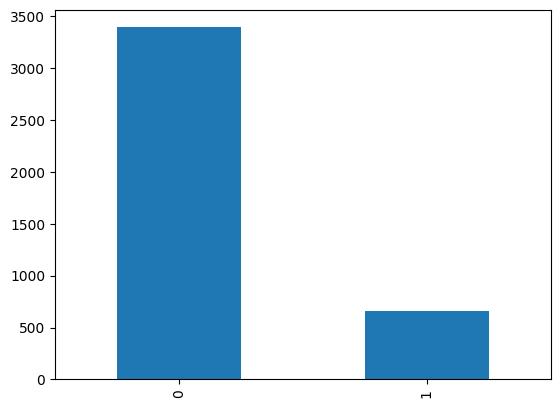

In [ ]:
#### Plot Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts().plot(kind='bar')

## Data Preparation

In [ ]:
data = pdf.copy()

In [ ]:
# Separate target variable and features
y = data['Attrition_Flag']
X = data.drop(['Attrition_Flag'], axis=1)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [ ]:
# Model
estimator = LogisticRegression()

# Create transformers for categorical and numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), ['Education_Level'])
        ,('num_standard', StandardScaler(), ['Customer_Age'])
        ,('num_minmax', MinMaxScaler(), ['Dependent_count'])
    ],
    remainder="passthrough",
)

# Create a logistic regression model using a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
    ,('estimator', estimator)
])

# Fit training data into model pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education_Level']),
                                                 ('num_standard',
                                                  StandardScaler(),
                                                  ['Customer_Age']),
                                                 ('num_minmax', MinMaxScaler(),
                                                  ['Dependent_count'])])),
                ('estimator', LogisticRegression())])

Accuracy: 0.84
Precision: 0.60
Recall: 0.02

Confusion Matrix:
[[2715    6]
 [ 510    9]]


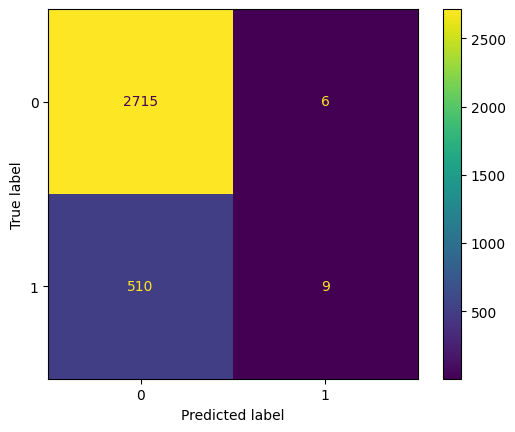

In [ ]:
# Make predictions on the train set
y_pred_train = pipeline.predict(X_train)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print(f"Accuracy: {accuracy_train:.2f}")
print(f"Precision: {precision_train:.2f}")
print(f"Recall: {recall_train:.2f}")
print(f"\nConfusion Matrix:")
print(cm_train)

cmd_train = ConfusionMatrixDisplay(cm_train)
cmd_train.plot()

Accuracy: 0.83
Precision: 0.20
Recall: 0.01

Confusion Matrix:
[[669   4]
 [136   1]]


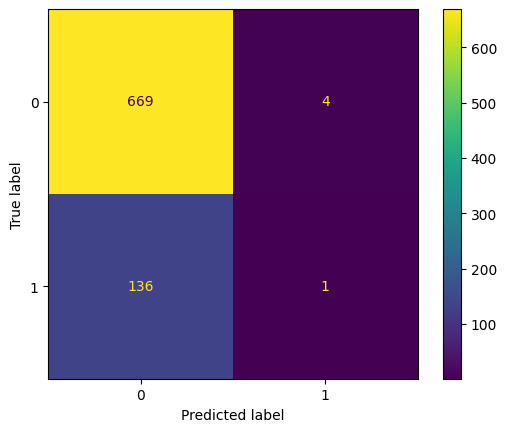

In [ ]:
# Make predictions on the test set
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print(f"Accuracy: {accuracy_test:.2f}")
print(f"Precision: {precision_test:.2f}")
print(f"Recall: {recall_test:.2f}")
print(f"\nConfusion Matrix:")
print(cm_test)

cmd_test = ConfusionMatrixDisplay(cm_test)
cmd_test.plot()